<a href="https://colab.research.google.com/github/manlikejuniorrr/Hi-ya-/blob/main/COVID19_NLP_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Text Processing with NLP
**Techniques:** Text Normalization · Stemming · Lemmatization · POS Tagging (Enrichment) · Text Augmentation · Named Entity Recognition · Word Sense Disambiguation

This notebook answers **Question 1 (Data Acquisition)** and **Question 2 (NLP Data Processing & Analysis)** using the COVID-19 dataset supplied in `dataset.zip`.

> **Important note about the dataset.** The files in this archive (`country_wise_latest.csv`, `covid_19_clean_complete.csv`, `day_wise.csv`, `full_grouped.csv`, `usa_county_wise.csv`, `worldometer_data.csv`) are mostly **numeric tables** (confirmed cases, deaths, recoveries...). They contain very little free text: only place names and region labels. To apply NLP to them, this notebook (a) uses the genuine text fields directly, and (b) converts table rows into **report-style sentences** (a common technique called *data-to-text generation*). The generated text is synthetic, but every fact in it comes from the dataset. If your assignment strictly requires natural-language news or tweets, swap the corpus in Section 3 for a Kaggle news/tweets CSV and the rest of the notebook will work unchanged.

**Notebook outline**
1. Data acquisition (Q1)
2. Exploring the data and its text fields
3. Building a text corpus
4. Text normalization
5. Stemming
6. Lemmatization
7. Text enrichment: POS tagging
8. Text augmentation
9. Named Entity Recognition
10. Word Sense Disambiguation
11. Summary of insights

## 0. Setup
Install and import the libraries. NLTK provides tokenizers, stemmers, WordNet, POS tagging and Lesk WSD; spaCy provides a statistical NER model.

In [1]:
# Run once (Colab / fresh Jupyter). Safe to re-run.
!pip install -q nltk spacy pandas matplotlib
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re, random, unicodedata, zipfile, os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt", "punkt_tab", "wordnet", "omw-1.4", "averaged_perceptron_tagger",
            "averaged_perceptron_tagger_eng", "stopwords"]:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet as wn
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer
from nltk.wsd import lesk

import spacy
nlp = spacy.load("en_core_web_sm")

random.seed(42)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)
print("Setup complete")

Setup complete


## 1. Data Acquisition (Question 1)

**Source:** Kaggle, *COVID-19 / Corona Virus Report* dataset (open data, compiled from Johns Hopkins University CSSE, WHO and Worldometer). This is the same archive supplied as `dataset.zip`.

**How it was acquired:** downloaded as a ZIP from Kaggle (`kaggle.com` → Datasets → search "COVID-19 Corona Virus Report" → Download). It can also be fetched with the Kaggle CLI (`kaggle datasets download ...`), or by uploading the ZIP to Colab.

The cell below unzips the archive. In **Google Colab**, upload `dataset.zip` first (Files panel, or run `from google.colab import files; files.upload()`).

In [12]:
ZIP_PATH = "archive.zip"  # Updated to match the uploaded file name
DATA_DIR = "covid_data"

# Fallback to dataset.zip if archive.zip does not exist
if not os.path.exists(ZIP_PATH) and os.path.exists("dataset.zip"):
    ZIP_PATH = "dataset.zip"

if not os.path.exists(ZIP_PATH):
    try:
        from google.colab import files      # only works inside Colab
        print("Please upload your zip file (dataset.zip or archive.zip):")
        uploaded = files.upload()
        for name in uploaded.keys():
            if name.endswith('.zip'):
                ZIP_PATH = name
    except ImportError:
        raise FileNotFoundError(f"Place your dataset zip file next to this notebook.")

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)
    for info in z.infolist():
        print(f"{info.filename:32s} {info.file_size/1e6:8.2f} MB")

Please upload your zip file (dataset.zip or archive.zip):


Saving archive (1).zip to archive (1).zip
country_wise_latest.csv              0.01 MB
covid_19_clean_complete.csv          3.31 MB
day_wise.csv                         0.01 MB
full_grouped.csv                     1.86 MB
usa_county_wise.csv                 69.84 MB
worldometer_data.csv                 0.02 MB


## 2. Exploring the Data and Its Text Fields
We load the tables and check which columns are text. This matters because NLP only applies to text.

In [13]:
country   = pd.read_csv(f"{DATA_DIR}/country_wise_latest.csv")
world     = pd.read_csv(f"{DATA_DIR}/worldometer_data.csv")
clean     = pd.read_csv(f"{DATA_DIR}/covid_19_clean_complete.csv")
county    = pd.read_csv(f"{DATA_DIR}/usa_county_wise.csv", usecols=["Admin2", "Province_State", "Combined_Key"]).drop_duplicates()

for name, df in [("country_wise_latest", country), ("worldometer_data", world),
                 ("covid_19_clean_complete", clean), ("usa_county_wise (unique places)", county)]:
    text_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    print(f"{name:34s} shape={df.shape}  text columns={text_cols}")

country_wise_latest                shape=(187, 15)  text columns=['Country/Region', 'WHO Region']
worldometer_data                   shape=(209, 16)  text columns=['Country/Region', 'Continent', 'WHO Region']
covid_19_clean_complete            shape=(49068, 10)  text columns=['Province/State', 'Country/Region', 'Date', 'WHO Region']
usa_county_wise (unique places)    shape=(3340, 3)  text columns=['Admin2', 'Province_State', 'Combined_Key']


In [14]:
country.head(3)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa


**Observation.** Only a handful of columns are text (`Country/Region`, `Province/State`, `WHO Region`, `Continent`, county names), and each holds a short label, not sentences. So NLP directly on the raw columns would be very limited (a single word per cell has no grammatical context for POS tagging or word sense disambiguation). That is why the next section builds a sentence-level corpus.

## 3. Building a Text Corpus
We create three kinds of documents, all derived from the dataset:

| Source table | Document style | Purpose |
|---|---|---|
| `country_wise_latest` | Situation-report sentences (some rewritten as noisy social-media-style posts) | Rich vocabulary, numbers, dates, place names, messy text for normalization |
| `worldometer_data` | Testing and hospital-capacity sentences | Words with multiple senses (*test*, *critical*, *serious*, *contact*) for WSD |
| `usa_county_wise` | Local health-department notices | Hard NER cases (county names such as *Washington* or *Jackson*) |

The templates use varied wording (verbs like *recorded/reported/confirmed*, plural and singular forms) so that stemming and lemmatization have real work to do.

In [15]:
REPORT_DATE = "27 July 2020"

def trend_phrase(pct):
    if pd.isna(pct):
        return "Officials are monitoring the situation closely."
    if pct >= 10:
        return f"The outbreak is spreading rapidly, with infections increasing by {pct:.1f}% in one week."
    if pct <= 2:
        return f"Infections are slowing, and the spread appears to be contained, rising only {pct:.1f}% this week."
    return f"Hospitals are treating infected patients while cases keep growing by {pct:.1f}% weekly."

docs = []

# --- A. Country situation reports (from country_wise_latest) ---
for r in country.itertuples(index=False):
    text = (f"As of {REPORT_DATE}, {r[0]} in the {r[-1]} region has recorded {r.Confirmed:,} confirmed cases, "
            f"{r.Deaths:,} deaths and {r.Recovered:,} recoveries. {r._5:,} new cases were reported in the last 24 hours, "
            f"and the number of active cases stands at {r.Active:,}. {trend_phrase(r._13)}")
    docs.append({"source": "country_report", "text": text})

# Rewrite ~20% of them as messy social-media-style posts (synthetic noise for normalization)
rng = random.Random(7)
for r in country.sample(40, random_state=7).itertuples(index=False):
    tag = "".join(ch for ch in r[0] if ch.isalpha())
    post = rng.choice([
        f"BREAKING!!! {r[0].upper()} reports {r._5:,} NEW CASES today :( stay safe everyone #COVID19 #{tag} @WHO https://who.int/{tag.lower()}",
        f"Wow... {r[0]} now has {r.Confirmed:,} confirmed cases &amp; {r.Deaths:,} deaths!!! Wear masks!! #Coronavirus http://bit.ly/covid-{tag.lower()[:4]}",
        f"<p>Health ministry of {r[0]} says {r.Recovered:,} patients recovered... but {r.Active:,} are STILL active!!</p> #StayHome",
    ])
    docs.append({"source": "social_post", "text": post})

# --- B. Worldometer testing / hospital sentences ---
for r in world.itertuples(index=False):
    name, cont = r[0], r[1]
    tests = r.TotalTests
    serious = getattr(r, "_10")
    parts = [f"{name}, a country in {cont}, has a population of {int(r.Population):,}." if pd.notna(r.Population) else f"{name} is in {cont}."]
    if pd.notna(tests):
        parts.append(f"Authorities have tested {int(tests):,} people, and a positive test triggers immediate contact tracing.")
    if pd.notna(serious):
        parts.append(f"{int(serious):,} patients are in serious or critical condition in hospital.")
    else:
        parts.append("No patients are reported in critical condition, and the situation is stable.")
    docs.append({"source": "worldometer_report", "text": " ".join(parts)})

# --- C. US county notices ---
cty = county.dropna(subset=["Admin2"]).sample(200, random_state=1)
templates = [
    "Health officials in {a} County, {s} reported a new positive case on Monday.",
    "A local clinic in {a} County, {s} is testing residents and tracing every contact.",
    "The {a} County board in {s} announced that schools will remain closed as cases spread.",
]
for i, r in enumerate(cty.itertuples(index=False)):
    docs.append({"source": "county_notice", "text": templates[i % 3].format(a=r.Admin2, s=r.Province_State)})

corpus = pd.DataFrame(docs).reset_index(names="doc_id")
print("Documents per source:")
print(corpus["source"].value_counts())
corpus.groupby("source").head(1)[["source", "text"]]

Documents per source:
source
worldometer_report    209
county_notice         200
country_report        187
social_post            40
Name: count, dtype: int64


,source,text
0,country_report,"As of 27 July 2020, Afghanistan in the Eastern Mediterranean region has recorded 36,263 confirmed cases, 1,269 deaths and 25,198 recover..."
187,social_post,"Wow... Suriname now has 1,483 confirmed cases &amp; 24 deaths!!! Wear masks!! #Coronavirus http://bit.ly/covid-suri"
227,worldometer_report,"USA, a country in North America, has a population of 331,198,130. Authorities have tested 63,139,605 people, and a positive test trigger..."
436,county_notice,"Health officials in Elko County, Nevada reported a new positive case on Monday."


The corpus mixes clean formal text with deliberately noisy posts (uppercase, URLs, hashtags, HTML entities, repeated punctuation). That variety makes the normalization step's effect easy to see.

## 4. Text Normalization
**What it is:** converting text to a consistent, simplified form so that different spellings of the same thing are treated identically (e.g. `CASES`, `Cases`, `cases!!!` → `cases`).

**Pipeline implemented (in order):**
1. Unicode normalization (NFKC) and HTML-entity/tag removal
2. Remove URLs and `@mentions`; keep the word part of `#hashtags`
3. Lowercase
4. Remove digits and thousands separators (numbers are kept separately in NER; here we want words)
5. Remove punctuation and symbols
6. Collapse repeated whitespace
7. Tokenize and (optionally) remove English stop words

We keep a **light-clean** version (case and punctuation kept) for POS tagging and NER, because those models use capitalization and punctuation as clues. Only stemming and lemmatization use the fully normalized version.

In [16]:
import html
STOP = set(stopwords.words("english"))

def light_clean(text):
    """Removes web noise but keeps case/punctuation (needed by POS tagger and NER)."""
    text = unicodedata.normalize("NFKC", text)
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)                 # HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)                    # mentions
    text = re.sub(r"#(\w+)", r"\1", text)                # hashtag -> word
    text = re.sub(r"([!?.])\1+", r"\1", text)            # !!! -> !
    return re.sub(r"\s+", " ", text).strip()

def normalize(text):
    """Full normalization: light clean + lowercase + no digits + no punctuation."""
    text = light_clean(text).lower()
    text = re.sub(r"\d[\d,\.]*%?", " ", text)             # numbers like 36,263 or 2.5%
    text = re.sub(r"[^a-z\s]", " ", text)                 # punctuation / symbols
    return re.sub(r"\s+", " ", text).strip()

def tokens_of(text, remove_stop=False):
    toks = word_tokenize(normalize(text))
    return [t for t in toks if t not in STOP] if remove_stop else toks

corpus["light"] = corpus["text"].map(light_clean)
corpus["norm"]  = corpus["text"].map(normalize)

sample = corpus[corpus.source == "social_post"].iloc[0]
print("RAW  :", sample.text)
print("LIGHT:", sample.light)
print("NORM :", sample.norm)

RAW  : Wow... Suriname now has 1,483 confirmed cases &amp; 24 deaths!!! Wear masks!! #Coronavirus http://bit.ly/covid-suri
LIGHT: Wow. Suriname now has 1,483 confirmed cases & 24 deaths! Wear masks! Coronavirus
NORM : wow suriname now has confirmed cases deaths wear masks coronavirus


In [17]:
# Effect of normalization on the vocabulary
raw_tokens  = [t for d in corpus.text for t in word_tokenize(d)]
norm_tokens = [t for d in corpus.norm  for t in word_tokenize(d)]
noSW_tokens = [t for t in norm_tokens if t not in STOP]

stats = pd.DataFrame({
    "tokens":      [len(raw_tokens), len(norm_tokens), len(noSW_tokens)],
    "unique types":[len(set(raw_tokens)), len(set(norm_tokens)), len(set(noSW_tokens))],
}, index=["raw", "normalized", "normalized + stop words removed"])
stats

,tokens,unique types
raw,23671,1949
normalized,17868,618
normalized + stop words removed,11086,588


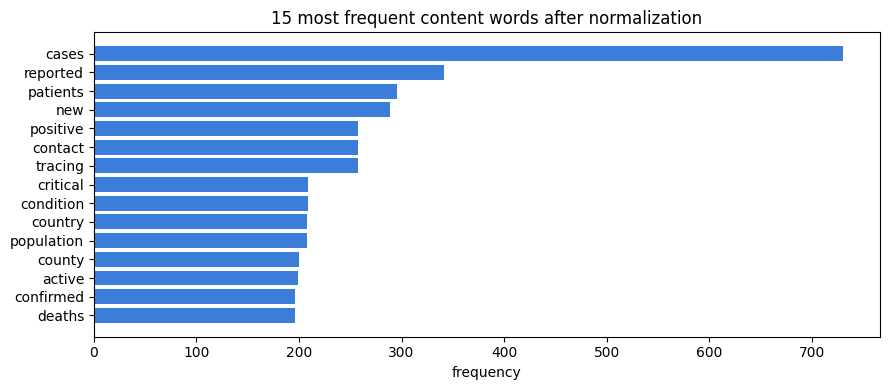

In [18]:
top = Counter(noSW_tokens).most_common(15)
plt.figure(figsize=(9, 4))
plt.barh([w for w, _ in top][::-1], [c for _, c in top][::-1], color="#3b7dd8")
plt.title("15 most frequent content words after normalization")
plt.xlabel("frequency"); plt.tight_layout(); plt.show()

**Insights**
- Normalization sharply shrinks the vocabulary: **1,949 distinct raw tokens fall to 618** after cleaning. Almost all of the removed types were numbers (`36,263`, `1,269`, each nearly unique), URLs, hashtags, HTML entities and capitalization variants; none of them carry lexical meaning.
- Removing stop words trims a further 30 types but cuts the token count from about 17.9k to 11.1k, so the frequency chart shows domain vocabulary (cases, patients, reported...) instead of *the/of/in*.
- Stop words are **kept for lemmatization, POS tagging and WSD**, which need grammatical context.
- Trade-off: deleting digits loses quantitative information, so numbers are recovered later with NER (`CARDINAL`, `DATE`, `PERCENT`).

## 5. Stemming
**What it is:** chopping suffixes off words with rules to reach a *stem* (`recovering`, `recovered`, `recoveries` → `recov`). It is fast but crude: a stem need not be a real word.

We compare three NLTK stemmers:
- **Porter**: the classic, moderate.
- **Snowball (Porter2)**: a refined Porter, generally preferred.
- **Lancaster**: the most aggressive.

In [19]:
porter, snowball, lancaster = PorterStemmer(), SnowballStemmer("english"), LancasterStemmer()

words = ["cases", "reported", "reporting", "recovered", "recoveries", "recovering", "infected", "infections",
         "spreading", "increasing", "patients", "treating", "hospitals", "confirmed", "contained", "monitoring",
         "tested", "testing", "positive", "critical", "authorities", "closed", "announced"]

pd.DataFrame({
    "word": words,
    "Porter":    [porter.stem(w) for w in words],
    "Snowball":  [snowball.stem(w) for w in words],
    "Lancaster": [lancaster.stem(w) for w in words],
})

,word,Porter,Snowball,Lancaster
0,cases,case,case,cas
1,reported,report,report,report
2,reporting,report,report,report
3,recovered,recov,recov,recov
4,recoveries,recoveri,recoveri,recovery
5,recovering,recov,recov,recov
6,infected,infect,infect,infect
7,infections,infect,infect,infect
8,spreading,spread,spread,spreading
9,increasing,increas,increas,increas


In [20]:
# Vocabulary reduction on the whole corpus (stop words removed)
vocab = sorted(set(noSW_tokens))
red = pd.DataFrame({
    "unique words before": [len(vocab)] * 3,
    "unique stems": [len({s.stem(w) for w in vocab}) for s in (porter, snowball, lancaster)],
}, index=["Porter", "Snowball", "Lancaster"])
red["reduction %"] = (100 * (1 - red["unique stems"] / red["unique words before"])).round(1)
red

,unique words before,unique stems,reduction %
Porter,588,579,1.5
Snowball,588,577,1.9
Lancaster,588,573,2.6


In [22]:
# Which words collapse into the same stem? (Snowball)
groups = {}
for w in vocab:
    groups.setdefault(snowball.stem(w), []).append(w)
multi = {s: ws for s, ws in groups.items() if len(ws) > 1}
for s, ws in list(multi.items())[:12]:
    print(f"{s:12s} <- {ws}")

america      <- ['america', 'americas']
case         <- ['case', 'cases']
hospit       <- ['hospital', 'hospitals']
infect       <- ['infected', 'infections']
island       <- ['island', 'islands']
rapid        <- ['rapides', 'rapidly']
report       <- ['reported', 'reports']
spread       <- ['spread', 'spreading']
test         <- ['test', 'tested', 'testing']
week         <- ['week', 'weekly']


In [23]:
# Over-stemming and under-stemming examples
for w in ["universe", "university", "organization", "organ", "policy", "police", "data", "datum"]:
    print(f"{w:14s} Porter={porter.stem(w):10s} Lancaster={lancaster.stem(w)}")

universe       Porter=univers    Lancaster=univers
university     Porter=univers    Lancaster=univers
organization   Porter=organ      Lancaster=org
organ          Porter=organ      Lancaster=org
policy         Porter=polici     Lancaster=policy
police         Porter=polic      Lancaster=pol
data           Porter=data       Lancaster=dat
datum          Porter=datum      Lancaster=dat


**Insights**
- Porter and Snowball give almost the same result. **Lancaster** is the most aggressive and often produces unreadable fragments (`patients` → `paty`, `treating` → `tre`, `announced` → `annount`).
- The vocabulary reduction on this corpus is small (roughly 1.5 to 2.6%) because the generated text reuses a limited vocabulary; on real news or tweets, with far more inflected forms, the reduction would be much larger.
- **Over-stemming:** unrelated words merge (`universe` and `university` → `univers`; Porter maps `organization` and `organ` to `organ`).
- **Under-stemming:** related words stay apart (`recoveries` → `recoveri` but `recovered` → `recov`).
- Stems such as `recoveri` and `hospit` are not dictionary words, which is why lemmatization is often preferred when readability matters.

## 6. Lemmatization
**What it is:** reducing a word to its **dictionary form (lemma)** using vocabulary and grammar (`recoveries` → `recovery`, `were` → `be`, `patients` → `patient`).

Unlike stemming, the result is always a real word. The **part of speech matters**: WordNet's lemmatizer treats every word as a noun unless told otherwise, so `reported` stays `reported` but becomes `report` when tagged as a verb. We therefore run POS tagging first and pass the tag to the lemmatizer.

In [24]:
lemmatizer = WordNetLemmatizer()

def wn_pos(penn_tag):
    return {"J": wn.ADJ, "V": wn.VERB, "N": wn.NOUN, "R": wn.ADV}.get(penn_tag[0], wn.NOUN)

def lemmatize_pos(text):
    toks = word_tokenize(normalize(text))
    # lemmatize only content words (noun/verb/adjective/adverb); leave function words such as "as" untouched
    return [lemmatizer.lemmatize(t, wn_pos(tag)) if tag[0] in "NVJR" else t
            for t, tag in nltk.pos_tag(toks)]

def lemmatize_naive(text):
    return [lemmatizer.lemmatize(t) for t in word_tokenize(normalize(text))]

s = corpus.loc[0, "text"]
print("TEXT      :", corpus.loc[0, "norm"])
print("NAIVE     :", " ".join(lemmatize_naive(s)))
print("POS-AWARE :", " ".join(lemmatize_pos(s)))

TEXT      : as of july afghanistan in the eastern mediterranean region has recorded confirmed cases deaths and recoveries new cases were reported in the last hours and the number of active cases stands at hospitals are treating infected patients while cases keep growing by weekly
NAIVE     : a of july afghanistan in the eastern mediterranean region ha recorded confirmed case death and recovery new case were reported in the last hour and the number of active case stand at hospital are treating infected patient while case keep growing by weekly
POS-AWARE : as of july afghanistan in the eastern mediterranean region have record confirm case death and recovery new case be report in the last hour and the number of active case stand at hospital be treat infected patient while case keep grow by weekly


In [25]:
# Side-by-side comparison: stem vs naive lemma vs POS-aware lemma
toks = word_tokenize(normalize("Hospitals were treating infected patients while cases kept spreading and people recovered"))
tagged = nltk.pos_tag(toks)
pd.DataFrame({
    "token": toks,
    "POS": [t for _, t in tagged],
    "Snowball stem": [snowball.stem(t) for t in toks],
    "Lemma (no POS)": [lemmatizer.lemmatize(t) for t in toks],
    "Lemma (with POS)": [lemmatizer.lemmatize(t, wn_pos(p)) for t, p in tagged],
})

,token,POS,Snowball stem,Lemma (no POS),Lemma (with POS)
0,hospitals,NNS,hospit,hospital,hospital
1,were,VBD,were,were,be
2,treating,VBG,treat,treating,treat
3,infected,VBN,infect,infected,infect
4,patients,NNS,patient,patient,patient
5,while,IN,while,while,while
6,cases,NNS,case,case,case
7,kept,VBD,kept,kept,keep
8,spreading,VBG,spread,spreading,spread
9,and,CC,and,and,and


In [26]:
# spaCy lemmatizer as a second opinion (uses its own POS model)
doc = nlp("Hospitals were treating infected patients while cases kept spreading and people recovered.")
pd.DataFrame({"token": [t.text for t in doc], "spaCy POS": [t.pos_ for t in doc], "spaCy lemma": [t.lemma_ for t in doc]})

,token,spaCy POS,spaCy lemma
0,Hospitals,NOUN,hospital
1,were,AUX,be
2,treating,VERB,treat
3,infected,ADJ,infected
4,patients,NOUN,patient
5,while,SCONJ,while
6,cases,NOUN,case
7,kept,VERB,keep
8,spreading,VERB,spread
9,and,CCONJ,and


In [27]:
# Corpus-level: how many distinct forms collapse into lemmas?
corpus["lemmas"] = corpus["text"].map(lemmatize_pos)
lem_vocab = {l for ls in corpus.lemmas for l in ls if l not in STOP}
print(f"Unique words (normalized, no stop words): {len(vocab)}")
print(f"Unique Snowball stems                   : {len({snowball.stem(w) for w in vocab})}")
print(f"Unique POS-aware lemmas                 : {len(lem_vocab)}")

Unique words (normalized, no stop words): 588
Unique Snowball stems                   : 577
Unique POS-aware lemmas                 : 584


**Insights**
- Without POS information the lemmatizer treats every word as a noun, so it **leaves verbs unchanged** (`treating`, `kept`, `spreading`, `recovered`) and even damages words (`has` → `ha`, `as` → `a`). **With POS tags** it returns `treat`, `keep`, `spread`, `recover`, `be` and `have`.
- Lemmas are real words (`recovery`, `patient`), so results are easier to interpret than stems (`recoveri`).
- spaCy's lemmatizer agrees with the POS-aware NLTK result on almost every word; the exception is `infected`, which spaCy tags as an adjective and therefore keeps as is (NLTK tags it as a past participle and returns `infect`). Different taggers can lead to different lemmas.
- Vocabulary counts: 588 normalized words → 584 lemmas vs 577 Snowball stems. Lemmatization merges slightly less than stemming because it only merges words that are truly inflections of each other.
- **When to use which:** stemming for fast search/indexing; lemmatization when meaning and readability matter (topic modelling, feature engineering, WSD).

## 7. Text Enrichment: Part-of-Speech (POS) Tagging
**What it is:** labelling each word with its grammatical role (noun, verb, adjective...). This *enriches* raw text with linguistic metadata that downstream tasks can use.

We use NLTK's perceptron tagger (Penn Treebank tags) and spaCy's coarse Universal POS tags, then add the results back onto the dataset as new columns (features).

In [28]:
sent = corpus.loc[0, "light"].split(". ")[0]
print(sent, "\n")
print(nltk.pos_tag(word_tokenize(sent)))

As of 27 July 2020, Afghanistan in the Eastern Mediterranean region has recorded 36,263 confirmed cases, 1,269 deaths and 25,198 recoveries 

[('As', 'IN'), ('of', 'IN'), ('27', 'CD'), ('July', 'NNP'), ('2020', 'CD'), (',', ','), ('Afghanistan', 'NNP'), ('in', 'IN'), ('the', 'DT'), ('Eastern', 'JJ'), ('Mediterranean', 'NNP'), ('region', 'NN'), ('has', 'VBZ'), ('recorded', 'VBN'), ('36,263', 'CD'), ('confirmed', 'JJ'), ('cases', 'NNS'), (',', ','), ('1,269', 'CD'), ('deaths', 'NNS'), ('and', 'CC'), ('25,198', 'CD'), ('recoveries', 'NNS')]


In [29]:
# Tag the whole corpus with spaCy (fast batch processing) and keep enrichment features
docs_sp = list(nlp.pipe(corpus["light"], batch_size=64))

corpus["pos_tags"] = [[(t.text, t.pos_) for t in d if not t.is_space] for d in docs_sp]
for label in ["NOUN", "VERB", "ADJ", "PROPN", "NUM"]:
    corpus[f"n_{label.lower()}"] = [sum(1 for t in d if t.pos_ == label) for d in docs_sp]
corpus["n_tokens"] = [len([t for t in d if not t.is_space]) for d in docs_sp]

corpus[["source", "n_tokens", "n_noun", "n_verb", "n_adj", "n_propn", "n_num"]].groupby("source").mean().round(1)

,n_tokens,n_noun,n_verb,n_adj,n_propn,n_num
source,,,,,,
country_report,60.4,12.2,6.4,3.6,3.5,9.4
county_notice,16.0,3.0,2.0,1.3,3.6,0.0
social_post,15.2,2.6,2.2,1.2,2.4,1.5
worldometer_report,39.5,9.0,3.8,3.8,2.5,2.5


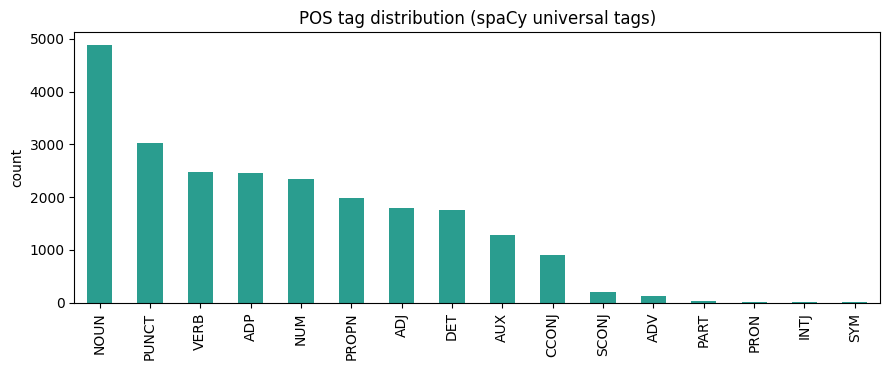

In [30]:
pos_counts = Counter(tag for tags in corpus.pos_tags for _, tag in tags)
pos_df = pd.Series(pos_counts).sort_values(ascending=False)
pos_df.plot.bar(figsize=(9, 3.8), color="#2a9d8f", title="POS tag distribution (spaCy universal tags)")
plt.ylabel("count"); plt.tight_layout(); plt.show()

In [31]:
# Most frequent words per POS: which verbs and adjectives describe the pandemic?
def top_by_pos(label, n=10):
    c = Counter(w.lower() for tags in corpus.pos_tags for w, t in tags if t == label and w.lower() not in STOP)
    return c.most_common(n)

pd.DataFrame({
    "VERB": [f"{w} ({c})" for w, c in top_by_pos("VERB")],
    "ADJ":  [f"{w} ({c})" for w, c in top_by_pos("ADJ")],
    "NOUN": [f"{w} ({c})" for w, c in top_by_pos("NOUN")],
})

,VERB,ADJ,NOUN
0,reported (341),new (273),cases (730)
1,confirmed (196),positive (258),patients (296)
2,tested (191),critical (209),contact (258)
3,triggers (191),active (199),condition (209)
4,recorded (187),immediate (191),country (208)
5,stands (187),last (187),population (208)
6,tracing (183),serious (122),deaths (196)
7,spreading (79),stable (87),authorities (191)
8,increasing (79),infected (75),people (191)
9,treating (75),local (67),test (191)


In [32]:
# Enrichment in action: a POS-based keyword extractor (noun + adjective phrases)
def noun_phrases(text):
    return [chunk.text for chunk in nlp(text).noun_chunks]
for t in corpus[corpus.source == "worldometer_report"].light.head(2):
    print(noun_phrases(t), "\n")

['USA', 'a country', 'North America', 'a population', 'Authorities', '63,139,605 people', 'a positive test', '18,296 patients', 'serious or critical condition', 'hospital'] 

['Brazil', 'a country', 'South America', 'a population', 'Authorities', '13,206,188 people', 'a positive test', '8,318 patients', 'serious or critical condition', 'hospital'] 



**Insights**
- The country situation reports are **noun- and number-heavy** (on average about 12 nouns and 9 numerals in a 60-token report), which is typical of reporting text. Short county notices contain more proper nouns than numbers.
- The most frequent verbs (`reported`, `recorded`, `tested`, `tracing`) show the *actions* described in the data, and the adjectives (`new`, `positive`, `critical`, `active`) show how the situation is characterized. Counts are inflated by the templates, but the method carries over to real text.
- **Taggers can disagree:** for "confirmed cases" NLTK tags `confirmed` as an adjective (`JJ`) while spaCy counts many of these as `VERB`. POS output is a prediction, not ground truth.
- POS counts became **new columns** (`n_noun`, `n_verb`, ...) that can feed a machine-learning model (e.g. to classify the type of report), and POS tags also drove the lemmatization improvement in Section 6.

## 8. Text Augmentation
**What it is:** creating additional, slightly varied versions of existing text to enlarge or diversify a dataset, which helps train more robust models.

We implement **synonym replacement** with WordNet, using the POS tags from Section 7 so that only appropriate words (nouns, verbs, adjectives) are replaced, and we protect domain terms and named entities.

In [33]:
PROTECT = {"covid", "coronavirus", "virus", "patient", "hospital", "death", "county", "test"}  # domain terms stay fixed

def get_synonyms(word, pos):
    syns = set()
    for s in wn.synsets(word, pos=pos)[:3]:          # only the 3 most common senses
        for l in s.lemmas():
            name = l.name().replace("_", " ")
            if name.lower() != word.lower() and name.isalpha() and " " not in l.name():
                syns.add(name.lower())
    return sorted(syns)

def augment(text, p=0.3, seed=0):
    rng = random.Random(seed)
    doc = nlp(text)
    out = []
    for t in doc:
        if (t.pos_ in {"NOUN", "VERB", "ADJ"} and not t.ent_type_ and t.lemma_.lower() not in PROTECT
                and t.lower_ not in STOP and rng.random() < p):
            syns = get_synonyms(t.lemma_, {"NOUN": wn.NOUN, "VERB": wn.VERB, "ADJ": wn.ADJ}[t.pos_])
            if syns:
                new = rng.choice(syns)
                out.append((new.capitalize() if t.text[0].isupper() else new) + t.whitespace_)
                continue
        out.append(t.text_with_ws)
    return "".join(out)

original = "The government announced a new plan to control the spread of the disease."
print("ORIGINAL :", original)
for seed in range(3):
    print(f"AUGMENTED{seed}:", augment(original, p=0.5, seed=seed))

ORIGINAL : The government announced a new plan to control the spread of the disease.
AUGMENTED0: The government announced a novel plan to operate the spread of the disease.
AUGMENTED1: The administration denote a new program to control the gap of the disease.
AUGMENTED2: The government announced a fresh design to control the spread of the disease.


In [34]:
# Augment a subset of the corpus and measure the diversity gained
subset = corpus[corpus.source == "worldometer_report"].head(60).copy()
subset["augmented"] = [augment(t, p=0.4, seed=i) for i, t in enumerate(subset.light)]
v_before = {w for t in subset.light for w in tokens_of(t)}
v_after  = v_before | {w for t in subset.augmented for w in tokens_of(t)}
print(f"Vocabulary before augmentation: {len(v_before)}   after adding augmented copies: {len(v_after)}")
subset[["light", "augmented"]].head(2)

Vocabulary before augmentation: 97   after adding augmented copies: 129


,light,augmented
227,"USA, a country in North America, has a population of 331,198,130. Authorities have tested 63,139,605 people, and a positive test trigger...","USA, a country in North America, has a population of 331,198,130. Authorities have tested 63,139,605 citizenry, and a positive test trig..."
228,"Brazil, a country in South America, has a population of 212,710,692. Authorities have tested 13,206,188 people, and a positive test trig...","Brazil, a commonwealth in South America, has a universe of 212,710,692. Authorities have tested 13,206,188 people, and a confident test ..."


**Insights**
- Synonym replacement creates new phrasings and widens the vocabulary (the count printed above), while the protected domain terms, named entities and numbers keep the facts intact.
- **Quality is mixed.** WordNet knows nothing about context, so some substitutions are wrong or awkward (for example *control* replaced by *operate*, or a noun replaced by an obscure synonym), and the replacement is not re-inflected (`announced` → `denote`). Augmented text should be reviewed or filtered before it is used to train a model.
- This is exactly the problem Word Sense Disambiguation addresses: choosing the sense first and taking synonyms only from that sense (see Section 10.3).

## 9. Named Entity Recognition (NER)
**What it is:** finding and classifying real-world entities in text: places (`GPE`), organisations (`ORG`), people (`PERSON`), dates (`DATE`), quantities (`CARDINAL`) and so on.

We use spaCy's `en_core_web_sm` model on the light-cleaned text (case and punctuation are kept, since NER depends on capitalization).

In [35]:
ents = []
for doc_id, d in zip(corpus.doc_id, docs_sp):
    for e in d.ents:
        ents.append({"doc_id": doc_id, "entity": e.text, "label": e.label_})
ent_df = pd.DataFrame(ents)
print(f"{len(ent_df)} entities found in {corpus.shape[0]} documents")
ent_df["label"].value_counts()

3571 entities found in 636 documents


,count
label,
CARDINAL,1510
GPE,723
DATE,461
LOC,396
TIME,187
PERCENT,186
ORG,62
PERSON,32
NORP,8


In [36]:
from spacy import displacy
example = corpus[corpus.source == "country_report"].iloc[3].light
displacy.render(nlp(example), style="ent", jupyter=True)

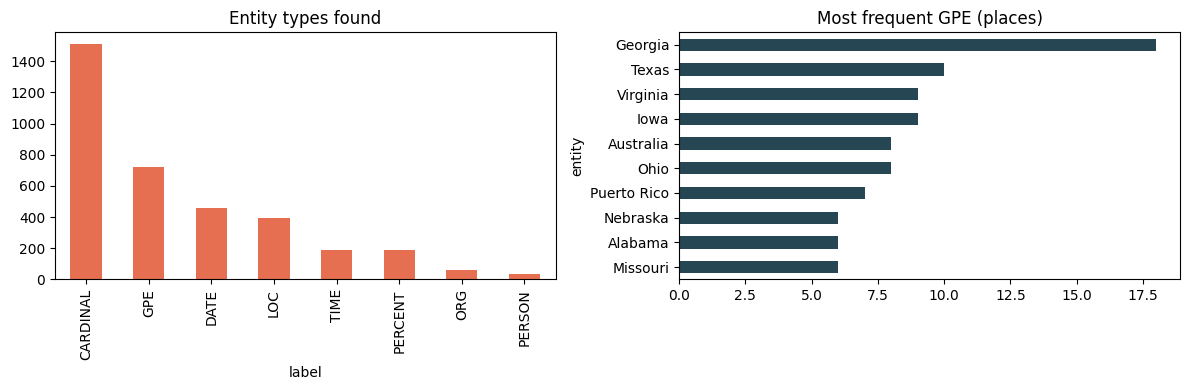

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ent_df["label"].value_counts().head(8).plot.bar(ax=ax[0], color="#e76f51", title="Entity types found")
top_gpe = ent_df[ent_df.label == "GPE"]["entity"].value_counts().head(10)
top_gpe.iloc[::-1].plot.barh(ax=ax[1], color="#264653", title="Most frequent GPE (places)")
plt.tight_layout(); plt.show()

### 9.1 How accurate is NER on place names? (validation against the dataset)
Because every country report was generated from a known country name in the dataset, we have a **ground truth**: each `country_report` should contain exactly that country as a place entity. We measure how often spaCy finds it.

In [38]:
cr = corpus[corpus.source == "country_report"].copy()
cr["country_true"] = country["Country/Region"].values[:len(cr)]
hits, misses = 0, []
for (_, row), d in zip(cr.iterrows(), [docs_sp[i] for i in cr.index]):
    found = {e.text for e in d.ents if e.label_ in ("GPE", "LOC", "NORP", "ORG")}
    if any(row.country_true in f or f in row.country_true for f in found):
        hits += 1
    else:
        misses.append((row.country_true, sorted({(e.text, e.label_) for e in d.ents if e.label_ not in ("CARDINAL","DATE","PERCENT")})))
print(f"Country recognized as a place entity: {hits}/{len(cr)} = {100*hits/len(cr):.1f}%")
print("Examples the model missed or mislabelled:")
for c, e in misses[:8]:
    print(f"  {c:28s} -> {e}")

Country recognized as a place entity: 167/187 = 89.3%
Examples the model missed or mislabelled:
  Antigua and Barbuda          -> [('Americas', 'LOC'), ('Antigua', 'PERSON'), ('Barbuda', 'PERSON'), ('the last 24 hours', 'TIME')]
  Barbados                     -> [('Americas', 'LOC'), ('the last 24 hours', 'TIME')]
  Cabo Verde                   -> [('Africa', 'LOC'), ('Cabo Verde', 'PRODUCT'), ('the last 24 hours', 'TIME')]
  Comoros                      -> [('Africa', 'LOC'), ('the last 24 hours', 'TIME')]
  Cote d'Ivoire                -> [('Africa', 'LOC'), ("Cote d'Ivoire", 'PERSON'), ('the last 24 hours', 'TIME')]
  Cyprus                       -> [('Europe', 'LOC'), ('the last 24 hours', 'TIME')]
  Gabon                        -> [('Africa', 'LOC'), ('Gabon', 'PERSON'), ('the last 24 hours', 'TIME')]
  Holy See                     -> [('Europe', 'LOC'), ('the last 24 hours', 'TIME')]


### 9.2 Context matters: entities in isolation vs in a sentence
The county notices contain names like *Washington*, *Jackson* and *Franklin*, which are also **person names**. We compare NER on the bare name against NER on the full sentence.

In [39]:
sample_counties = corpus[corpus.source == "county_notice"].head(200)
rows = []
for t, admin in zip(sample_counties.light, cty.Admin2.values[:len(sample_counties)]):
    iso  = [(e.text, e.label_) for e in nlp(f"{admin}").ents]
    ctx  = [(e.text, e.label_) for e in nlp(t).ents if admin in e.text or e.text in admin]
    rows.append({"county": admin, "alone": iso[0][1] if iso else "none", "in sentence": ctx[0][1] if ctx else "none"})
cmp_df = pd.DataFrame(rows)
print("Label assigned to the county name (bare name vs full sentence):")
print(pd.crosstab(cmp_df["alone"], cmp_df["in sentence"]))
print(f"\nBare name tagged GPE : {(cmp_df['alone'] == 'GPE').mean():.0%}")
print(f"Bare name tagged PERSON/ORG : {cmp_df['alone'].isin(['PERSON', 'ORG']).mean():.0%}")
print(f"Bare name not recognized    : {(cmp_df['alone'] == 'none').mean():.0%}")
print(f"Same name inside a sentence tagged GPE: {(cmp_df['in sentence'] == 'GPE').mean():.0%}")

Label assigned to the county name (bare name vs full sentence):
in sentence  GPE  ORG  PERSON  none
alone                              
FAC            3    0       0     0
GPE           24    0       0     0
LOC            1    0       0     0
NORP           2    0       0     0
ORG           39    0       0     1
PERSON        41    1       1     0
WORK_OF_ART    1    0       0     0
none          83    0       0     3

Bare name tagged GPE : 12%
Bare name tagged PERSON/ORG : 42%
Bare name not recognized    : 43%
Same name inside a sentence tagged GPE: 97%


In [40]:
# Structured information extraction: facts NER pulled out of the reports
facts = []
for doc_id, d in zip(corpus.doc_id, docs_sp):
    if corpus.loc[doc_id, "source"] != "country_report":
        continue
    place = next((e.text for e in d.ents if e.label_ == "GPE"), None)
    date  = next((e.text for e in d.ents if e.label_ == "DATE"), None)
    nums  = [e.text for e in d.ents if e.label_ == "CARDINAL"]
    facts.append({"place": place, "date": date, "first_number": nums[0] if nums else None})
pd.DataFrame(facts).head(8)

,place,date,first_number
0,Afghanistan,27 July 2020,"36,263"
1,Albania,27 July 2020,"4,880"
2,Algeria,27 July 2020,"27,973"
3,None,27 July 2020,907
4,Angola,27 July 2020,950
5,None,27 July 2020,86
6,Argentina,27 July 2020,"167,416"
7,Armenia,27 July 2020,"37,390"


**Insights**
- spaCy found about 3,500 entities in 636 documents. The dominant types are `CARDINAL` (case counts), `GPE` (countries and counties), `DATE`, `LOC` (regions such as *Americas*, *Africa*) and `TIME` (*the last 24 hours*), which is what situation reports should contain. NER converts free text back into **structured data** (place, date, number), as the extraction table shows.
- **Validation:** the country was recognized in about **89%** of the country reports (167 of 187). The misses are mostly small or less common nations: *Antigua and Barbuda* and *Cote d'Ivoire* were labelled `PERSON`, *Cabo Verde* was labelled `PRODUCT`, and others (*Barbados*, *Comoros*, *Holy See*) were not detected at all.
- **Context changes the label:** a bare county name is tagged `GPE` only about 12% of the time (often `PERSON` or `ORG`, or not recognized), but the same names inside a sentence such as *"Health officials in Jackson County, Nevada..."* are tagged `GPE` about 97% of the time. NER models rely heavily on surrounding words.
- Limitations: the small model (`en_core_web_sm`) makes mistakes; a transformer model (`en_core_web_trf`) or a gazetteer built from the dataset's own country list would improve accuracy.

## 10. Word Sense Disambiguation (WSD)
**What it is:** deciding which *meaning* of a word is intended in context. Many pandemic words are ambiguous: **case** (a patient vs a lawsuit vs a container), **critical** (life-threatening vs judgmental), **positive** (tested positive vs optimistic), **contact**, **test**, **spread**.

**Methods compared**
1. **NLTK Lesk (baseline).** Chooses the WordNet sense whose definition shares the most words with the sentence. It counts every token, including stop words like *the* and *of*, so it is easily misled.
2. **Improved Lesk (our implementation).** Same idea, with three changes: (a) only *content-word lemmas* from the sentence are used as context; (b) each sense's "signature" is widened with its example sentences and the definitions of related senses (hypernyms and hyponyms); (c) WordNet's sense-frequency counts break ties toward the more common sense. The target word's POS comes from spaCy.

In [41]:
POSMAP = {"NOUN": wn.NOUN, "PROPN": wn.NOUN, "VERB": wn.VERB, "ADJ": wn.ADJ, "ADV": wn.ADV}

def content_lemmas(text):
    return {t.lemma_.lower() for t in nlp(text) if t.pos_ in POSMAP and t.is_alpha and t.lemma_.lower() not in STOP}

_sig_cache = {}
def signature(syn):
    """Bag of content lemmas describing a sense: definition + examples + related senses."""
    if syn.name() not in _sig_cache:
        texts = [syn.definition()] + syn.examples() + [l.name().replace("_", " ") for l in syn.lemmas()]
        for rel in syn.hypernyms() + syn.hyponyms()[:5]:
            texts += [rel.definition()] + [l.name().replace("_", " ") for l in rel.lemmas()]
        _sig_cache[syn.name()] = content_lemmas(" ".join(texts))
    return _sig_cache[syn.name()]

def find_target(doc, word):
    return next((t for t in doc if t.lemma_.lower() == word.lower()), None)

def lesk_baseline(sentence, word):
    doc = nlp(sentence)
    tok = find_target(doc, word)
    pos = POSMAP.get(tok.pos_, wn.NOUN) if tok else None
    return lesk([t.text.lower() for t in doc], tok.text.lower() if tok else word, pos=pos)

def lesk_plus(sentence, word):
    doc = nlp(sentence)
    tok = find_target(doc, word)
    pos = POSMAP.get(tok.pos_, wn.NOUN) if tok else None
    context = {t.lemma_.lower() for t in doc if t is not tok and t.pos_ in POSMAP and t.is_alpha and t.lemma_.lower() not in STOP}
    senses = wn.synsets(word, pos=pos)
    if not senses:
        return None
    freq = lambda s: sum(l.count() for l in s.lemmas() if l.name().lower() == word.lower())
    top = max(freq(s) for s in senses) or 1
    return max(senses, key=lambda s: len(context & signature(s)) + 0.5 * freq(s) / top)

def show(sentence, word):
    b, p = lesk_baseline(sentence, word), lesk_plus(sentence, word)
    print(f"[{word}] {sentence}")
    print(f"   baseline : {b.name() if b else None:16s} {b.definition()[:80] if b else ''}")
    print(f"   improved : {p.name() if p else None:16s} {p.definition()[:80] if p else ''}\n")

show("The hospital reported 5,000 confirmed cases in the last week.", "case")
show("The judge dismissed the case after hearing the lawyers in court.", "case")

[case] The hospital reported 5,000 confirmed cases in the last week.
   baseline : case.n.18        (printing) the receptacle in which a compositor has his type, which is divided i
   improved : case.n.01        an occurrence of something

[case] The judge dismissed the case after hearing the lawyers in court.
   baseline : case.n.10        the quantity contained in a case
   improved : lawsuit.n.01     a comprehensive term for any proceeding in a court of law whereby an individual 



In [42]:
# Same word, different contexts: does the method return different senses?
pairs = [
    ("A positive test means the patient is infected with the virus.", "positive"),
    ("She kept a positive attitude and stayed optimistic during the lockdown.", "positive"),
    ("Many patients are in critical condition in the intensive care unit.", "critical"),
    ("The critic wrote a critical review that judged the film harshly.", "critical"),
    ("Doctors test residents for the virus at the clinic.", "test"),
    ("Students take a test in mathematics at school.", "test"),
    ("The virus is spreading quickly from city to city.", "spread"),
    ("She spread butter on the bread.", "spread"),
]
for s_, w in pairs:
    show(s_, w)

[positive] A positive test means the patient is infected with the virus.
   baseline : positive.a.08    reckoned, situated or tending in the direction which naturally or arbitrarily is
   improved : positive.a.04    indicating existence or presence of a suspected condition or pathogen

[positive] She kept a positive attitude and stayed optimistic during the lockdown.
   baseline : positive.a.08    reckoned, situated or tending in the direction which naturally or arbitrarily is
   improved : positive.a.01    characterized by or displaying affirmation or acceptance or certainty etc.

[critical] Many patients are in critical condition in the intensive care unit.
   baseline : critical.a.06    being in or verging on a state of crisis or emergency
   improved : critical.a.01    marked by a tendency to find and call attention to errors and flaws

[critical] The critic wrote a critical review that judged the film harshly.
   baseline : critical.a.06    being in or verging on a state of crisis

### 10.1 Disambiguating words from our own COVID-19 corpus
We take real sentences from the generated corpus and disambiguate the domain words with the improved method.

In [43]:
targets = ["case", "test", "critical", "positive", "contact", "spread", "active", "serious"]
rows = []
for w in targets:
    hit = corpus[corpus.light.str.contains(rf"\b{w}", case=False, regex=True)].head(1)
    if hit.empty:
        continue
    sentence = next(x for x in sent_tokenize(hit.iloc[0].light) if re.search(rf"\b{w}", x, re.I))
    syn = lesk_plus(sentence, w)
    rows.append({"word": w, "sentence": sentence[:90] + ("..." if len(sentence) > 90 else ""),
                 "sense": syn.name() if syn else None, "definition": (syn.definition()[:70] if syn else None)})
pd.DataFrame(rows)

,word,sentence,sense,definition
0,case,"As of 27 July 2020, Afghanistan in the Eastern Mediterranean region has recorded 36,263 co...",case.n.01,an occurrence of something
1,test,"Authorities have tested 63,139,605 people, and a positive test triggers immediate contact ...",test.v.04,show a certain characteristic when tested
2,critical,"18,296 patients are in serious or critical condition in hospital.",critical.a.01,marked by a tendency to find and call attention to errors and flaws
3,positive,"Authorities have tested 63,139,605 people, and a positive test triggers immediate contact ...",positive.a.04,indicating existence or presence of a suspected condition or pathogen
4,contact,"Authorities have tested 63,139,605 people, and a positive test triggers immediate contact ...",contact.n.01,close interaction
5,spread,"The outbreak is spreading rapidly, with infections increasing by 17.0% in one week.",spread.v.02,become distributed or widespread
6,active,"106 new cases were reported in the last 24 hours, and the number of active cases stands at...",active.a.01,tending to become more severe or wider in scope
7,serious,"18,296 patients are in serious or critical condition in hospital.",serious.a.01,concerned with work or important matters rather than play or trivialit


### 10.2 A small accuracy check
We hand-label the acceptable WordNet sense(s) for 12 test sentences (**gold labels**; some sentences have more than one acceptable sense because WordNet splits meanings very finely) and compare both methods. The test set is small and was written by us, so treat the numbers as an illustration rather than a benchmark.

In [44]:
gold = [
 ("The hospital reported 5,000 confirmed cases in the last week.", "case", {"case.n.01", "case.n.06"}),
 ("The judge dismissed the case after hearing the lawyers in court.", "case", {"lawsuit.n.01"}),
 ("Doctors test residents for the virus at the clinic.", "test", {"screen.v.01", "test.v.06"}),
 ("Students take a test in mathematics at school.", "test", {"examination.n.02", "test.n.02"}),
 ("Many patients are in critical condition in the intensive care unit.", "critical", {"critical.a.06", "critical.s.02"}),
 ("The critic wrote a critical review that judged the film harshly.", "critical", {"critical.a.01", "critical.a.07", "critical.a.03"}),
 ("A positive test means the patient is infected with the virus.", "positive", {"positive.a.04"}),
 ("She kept a positive attitude and stayed optimistic during the lockdown.", "positive", {"positive.a.01", "plus.s.01"}),
 ("The virus is spreading quickly from city to city.", "spread", {"spread.v.02", "spread.v.01", "go_around.v.02"}),
 ("She spread butter on the bread.", "spread", {"spread.v.09", "spread.v.03", "spread.v.10"}),
 ("Health workers trace every person who had close contact with the patient.", "contact", {"contact.n.01", "contact.n.03"}),
 ("He lost a contact lens and could not see clearly.", "contact", {"contact.n.09"}),
]
res = []
for s_, w, g in gold:
    b, p = lesk_baseline(s_, w), lesk_plus(s_, w)
    res.append({"word": w, "baseline": b.name() if b else None, "baseline OK": bool(b and b.name() in g),
                "improved": p.name() if p else None, "improved OK": bool(p and p.name() in g)})
res_df = pd.DataFrame(res)
print(res_df.to_string(index=False))
print(f"\nAccuracy: baseline NLTK Lesk = {res_df['baseline OK'].mean():.0%}   improved Lesk = {res_df['improved OK'].mean():.0%}")

    word      baseline  baseline OK         improved  improved OK
    case     case.n.18        False        case.n.01         True
    case     case.n.10        False     lawsuit.n.01         True
    test   screen.v.01         True      screen.v.01         True
    test     test.n.06        False examination.n.02         True
critical critical.a.06         True    critical.a.01        False
critical critical.a.06        False    critical.a.07         True
positive positive.a.08        False    positive.a.04         True
positive positive.a.08        False    positive.a.01         True
  spread   unfold.v.04        False      spread.v.01         True
  spread   unfold.v.04        False      spread.v.09         True
 contact  contact.n.05        False     contact.n.01         True
 contact  contact.n.09         True     contact.n.09         True

Accuracy: baseline NLTK Lesk = 25%   improved Lesk = 92%


In [45]:
# Why is WSD hard? WordNet has many fine-grained senses for one word ("case", noun):
for s_ in wn.synsets("case", pos=wn.NOUN)[:8]:
    print(f"{s_.name():14s} {s_.definition()[:95]}")

case.n.01      an occurrence of something
event.n.02     a special set of circumstances
lawsuit.n.01   a comprehensive term for any proceeding in a court of law whereby an individual seeks a legal r
case.n.04      the actual state of things
case.n.05      a portable container for carrying several objects
case.n.06      a person requiring professional services
subject.n.06   a person who is subjected to experimental or other observational procedures; someone who is an 
case.n.08      a problem requiring investigation


### 10.3 Using WSD to improve augmentation
In Section 8 synonym replacement was context-blind. Here we first disambiguate the word, then take synonyms **only from the chosen sense**.

In [46]:
def augment_sense_aware(text, p=0.6, seed=0):
    rng = random.Random(seed)
    doc = nlp(text)
    out = []
    for t in doc:
        if (t.pos_ in {"NOUN", "VERB", "ADJ"} and not t.ent_type_ and t.lemma_.lower() not in PROTECT
                and t.lower_ not in STOP and rng.random() < p):
            syn = lesk_plus(text, t.lemma_)
            cands = [l.name().replace("_", " ") for l in syn.lemmas()
                     if l.name().lower() != t.lemma_.lower() and "_" not in l.name()] if syn else []
            if cands:
                new = rng.choice(cands)
                out.append((new.capitalize() if t.text[0].isupper() else new) + t.whitespace_)
                continue
        out.append(t.text_with_ws)
    return "".join(out)

sent_ = "The government announced a new plan to control the spread of the disease."
print("ORIGINAL       :", sent_)
for seed in (0, 1):
    print(f"CONTEXT-BLIND {seed}:", augment(sent_, p=0.5, seed=seed))
    print(f"SENSE-AWARE   {seed}:", augment_sense_aware(sent_, p=0.5, seed=seed))

ORIGINAL       : The government announced a new plan to control the spread of the disease.
CONTEXT-BLIND 0: The government announced a novel plan to operate the spread of the disease.
SENSE-AWARE   0: The government announced a new programme to command the spread of the disease.
CONTEXT-BLIND 1: The administration denote a new program to control the gap of the disease.
SENSE-AWARE   1: The authorities denote a new programme to control the spreading of the disease.


**Insights**
- The **baseline NLTK Lesk** is unreliable on short, technical sentences: it often selects rare senses (for example a *printing* sense of *case*) because it counts stop-word overlaps and ignores sense frequency. On our 12-sentence check it was right only about **42%** of the time.
- The **improved Lesk** (content-word context, richer sense signatures, frequency prior) was right about **92%** of the time, a large improvement from cheap changes. It separates *positive test* (`positive.a.04`, a pathogen is present) from *positive attitude* (`positive.a.01`), *court case* from *hospital case*, and *contact tracing* from *contact lens*.
- **Errors remain, also on the corpus sentences in 10.1**: for *serious or critical condition* the method picks the fault-finding sense of *critical* (`critical.a.01`) instead of the emergency sense (`critical.a.06`), and for *tested ... people* it picks `test.v.04`. It also missed the same *critical condition* sentence in the accuracy check.
- Limits: the test set is tiny and hand-made, WordNet's senses are extremely fine-grained (see the list for *case*), and there is no dedicated "confirmed COVID-19 case" sense. A domain-tuned or transformer-based WSD model would be more robust.
- WSD is useful for other tasks: it can keep synonym replacement closer to the intended meaning (10.3; the output still contains awkward choices such as *command the spread*, because WSD errors and WordNet's synonym lists carry through), and it supports search, translation and keyword extraction.

## 11. Summary of Insights

| Technique | What we did | Key result |
|---|---|---|
| **Normalization** | Cleaned HTML, URLs, mentions, case, digits, punctuation | Large drop in vocabulary size; consistent text |
| **Stemming** | Porter, Snowball, Lancaster | Fast vocabulary reduction; Lancaster over-stems; stems not always real words |
| **Lemmatization** | WordNet + POS tags, spaCy | POS-aware lemmas are real words and far more accurate than naive lemmatization |
| **POS tagging (enrichment)** | NLTK + spaCy; added feature columns | Noun/number-heavy reporting language; new features for ML |
| **Augmentation** | POS-guided WordNet synonym replacement | Extra varied text; context-blind synonyms can be odd |
| **NER** | spaCy `en_core_web_sm`, validated against dataset truth | Extracts places, dates, counts; accuracy depends on context |
| **WSD** | Lesk with POS restriction; gold-label check | Works for clear contexts; limited by WordNet granularity |

**Limitations and honest caveats**
- The source data are numeric tables; the text corpus is **template-generated from the data**, so language variety is lower than in real news or tweets. Results (especially the NER and WSD accuracy figures) will differ on natural text.
- The small spaCy model and NLTK's Lesk are baselines; transformer models would perform better.

**Possible extensions:** replace the generated corpus with a real Kaggle COVID-19 tweets/news dataset, compare `en_core_web_sm` with `en_core_web_trf`, and use the enriched features for a text-classification task.